# A First look at the Data

## Introduction

In this section some basic analysis will be done in order to explain the structure of the data and perform a few sanity checks. Examples of simple plots of the raw data will be provided.

Import the required modules:

In [17]:
import mne
import os
import numpy as np
import os.path as op
import warnings
from mne_bids import (
    BIDSPath,
    print_dir_tree,
    read_raw_bids,
)

mne.viz.set_browser_backend("qt")  # or "matplotlib"

warnings.filterwarnings(
    "ignore"
)  # Suppresses MNE informational/runtime warnings for tutorial readability;
# for your own analyses, keep warnings enabled so you don't miss issues like duplicated events.

Using qt as 2D backend.


## File Overview

The chapter relies on the input file (embedded in the BIDS structure):

```
<BIDS_ROOT>/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif
```

You can inspect the full BIDS folder structure directly using `print_dir_tree(bids_root)` once `bids_root` is defined below.

## Loading the BIDS Data

The first step is to prepare the data for reading. The OPM data, which has been organized according to the BIDS format, will be used in this section. This involves setting the `data_path` which defines the MNE BIDS folder.

Specify the BIDS parameters. The `data_path` is dependent on where you downloaded and stored the data.

In [3]:
subject = "01"
session = "01"
task = "SpAtt"
run = "01"
meg_suffix = "meg"
meg_extension = ".fif"
events_suffix = "events"
events_extension = ".tsv"

# data_path = 'E:/Data/Cerca'  # Update this to wherever you downloaded and stored the data
data_path = "Sub_01/Data"


bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    run=run,
    suffix=meg_suffix,
    extension=meg_extension,
    root=bids_root,
)

# Show the BIDS folder structure
print_dir_tree(bids_root)

|Cerca_Spatt_BIDS/
|--- README
|--- dataset_description.json
|--- participants.json
|--- participants.tsv
|--- trans
|--- derivatives/
|------ Freesurfer/
|--------- T1s/
|------------ bem/
|--------------- T1-head-dense.fif
|--------------- T1-head-medium.fif
|--------------- T1-head-sparse.fif
|--------------- T1-head.fif
|--------------- brain.surf
|--------------- inner_skull.surf
|--------------- outer_skin.surf
|--------------- outer_skull.surf
|--------------- watershed/
|------------------ T1_brain_surface
|------------------ T1_inner_skull_surface
|------------------ T1_outer_skin_surface
|------------------ T1_outer_skull_surface
|------------ label/
|--------------- BA_exvivo.ctab
|--------------- BA_exvivo.thresh.ctab
|--------------- aparc.annot.DKTatlas.ctab
|--------------- aparc.annot.a2009s.ctab
|--------------- aparc.annot.ctab
|--------------- lh.BA1_exvivo.label
|--------------- lh.BA1_exvivo.thresh.label
|--------------- lh.BA2_exvivo.label
|--------------- lh.BA2_

After the path have been defined the data can be read:

In [4]:
print(bids_path)
raw = read_raw_bids(bids_path=bids_path, verbose=False, extra_params={"preload": True})

Sub_01/Data/Cerca_Spatt_BIDS/sub-01/ses-01/sub-01_ses-01_task-SpAtt_run-01_meg.fif


## Inspecting the Data

To obtain some basic information from the `.fif` file write:

In [5]:
print(raw)

<Raw | sub-01_ses-01_task-SpAtt_run-01_meg.fif, 219 x 1241952 (1655.9 s), ~2.03 GiB, data loaded>


The dataset has a size of 2.52 GB and spans a total recording duration of 2053.1 seconds. After downsampling to 750 Hz, this yields 1,539,808 sample points across the entire recording. The data were collected from 219 channels, comprising 192 magnetometer sensors and 27 stimulus-related channels.

To get some additional information:

In [6]:
print(raw.info)

<Info | 16 non-empty values
 bads: []
 ch_names: Trigger 1, Trigger 2, Trigger 3, Trigger 4, Trigger 5, Trigger ...
 chs: 27 Stimulus, 192 Magnetometers
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dev_head_t: MEG device -> head transform
 device_info: 2 items (dict)
 dig: 4309 items (3 Cardinal, 4306 Extra)
 experimenter: mne_anonymize
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 line_freq: 50.0
 lowpass: 250.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 219
 projs: []
 sfreq: 750.0 Hz
 subject_info: <subject_info | his_id: sub-01, sex: 0, hand: 0>
>


This information shows the important parameters of the dataset. For instance, the sampling frequency is 750 Hz (sfreq). The data was lowpass filtered at 250.0 Hz (lowpass) prior to downsampling. The experimenter is anonymised and the recording time and date removed to comply with GDPR rules.

**Question 1:** What role does the 250 Hz analogue low‑pass filter play in the data acquisition process? (See Chapter 3 in [1])

### Understanding the triaxial sensor layout

As a first step, inspect the sensor information by printing the labels of the first 40 channels:

In [7]:
ch_names = raw.info["ch_names"]
print(ch_names[:40])

['Trigger 1', 'Trigger 2', 'Trigger 3', 'Trigger 4', 'Trigger 5', 'Trigger 6', 'Trigger 7', 'Trigger 8', 'Trigger 9', 'Trigger 10', 'Trigger 11', 'BNC 1 Z', 'BNC 2 Z', 'BNC 3 Z', 'BNC 4 Z', 'BNC 5 Z', 'BNC 6 Z', 'BNC 7 Z', 'BNC 8 Z', 'BNC 9 Z', 'BNC 10 Z', 'BNC 11 Z', 'BNC 12 Z', 'BNC 13 Z', 'BNC 14 Z', 'BNC 15 Z', 'BNC 16 Z', 'F1 A1 Z', 'F1 A1 Y', 'F1 A1 X', 'F3 A3 Z', 'F3 A3 Y', 'F3 A3 X', 'F5 A6 Z', 'F5 A6 Y', 'F5 A6 X', 'F7 A4 Z', 'F7 A4 Y', 'F7 A4 X', 'F9 C8 Z']


The first 11 channels are trigger lines. These are followed by 16 BNC channels, which can be used to acquire digitized analogue input. The subsequent OPM sensors are organized as triplets, one triplet per sensor. Each sensor measures the field in 3 directions, denoted by X, Y and Z. The Z direction corresponds to conventional magnetometers in SQUID-based MEG systems, measuring the field perpendicular to the scalp surface.

To show the layout of the sensors write:

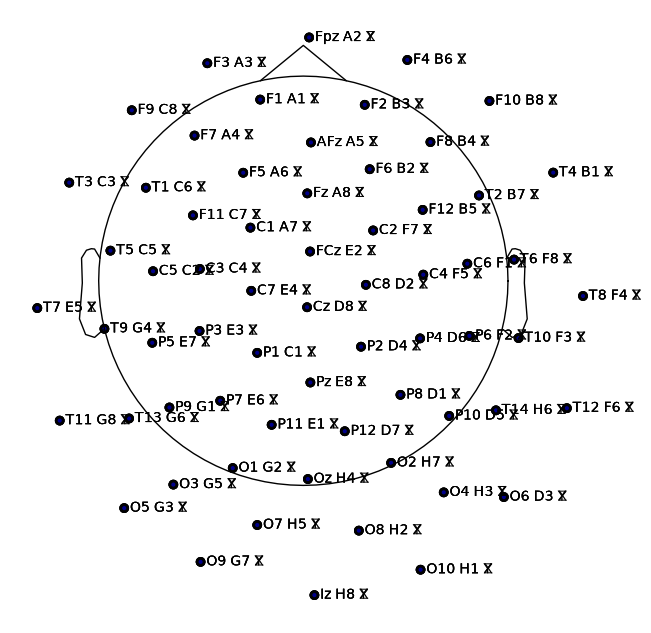

In [8]:
raw.plot_sensors(kind="topomap", show_names=True);

We will here isolate the labels for the X, Y and Z directions:

In [9]:
OPMX = [item for item in raw.ch_names if item.endswith("X")]
OPMY = [item for item in raw.ch_names if item.endswith("Y")]
OPMZ = [
    item for item in raw.ch_names if item.endswith("Z") and not item.startswith("BNC")
]  # exclude 'BNC n Z' channels, which are not OPM sensors

**Question 2:** Why is the field from the Z-axis sensor typically easier to interpret than the field from the X- and Y-axes?

In order to calculate and plot the power, a few flat sensors must first be marked as bad:

In [10]:
ch_names = raw.info["ch_names"]
bad_chs = ["B4", "H6"]
# Substring matching (rather than exact match) ensures all three axes (X, Y, Z) of a flagged
# sensor are marked bad together, e.g. 'B4' matches 'B4X', 'B4Y', and 'B4Z'.
bad_channels = [name for name in ch_names if any(ch in name for ch in bad_chs)]
raw.info["bads"] = bad_channels

# Print the bad channels
print("Bad channels marked:", raw.info["bads"])

Bad channels marked: ['F8 B4 Z', 'F8 B4 Y', 'F8 B4 X', 'T14 H6 Z', 'T14 H6 Y', 'T14 H6 X']


### Estimating the power spectra
The `raw` object allows for a simple inspection of the data by estimating the power spectral density (PSD). As a first step we compute the PSDs of all the OPM sensors over the 0–120 Hz frequency range using the MNE functions. Since the sampling frequency is 750 Hz, we choose $N_{FFT}$ = 1500 to obtain a 0.5 Hz spectral resolution. The Welch method is used with 50% overlapping time-windows. By default a Hamming taper is applied to each time-window prior to computing the Fourier transform.

In [11]:
n_fft = 1500
raw_PSDZ = raw.compute_psd(
    method="welch",
    fmin=0.0,
    fmax=120,
    picks=OPMZ,
    n_fft=n_fft,
    n_overlap=int(n_fft / 2),
)

Effective window size : 2.000 (s)


To plot the PSDs for the OPMs for the Z direction:

Plotting power spectral density (dB=True).


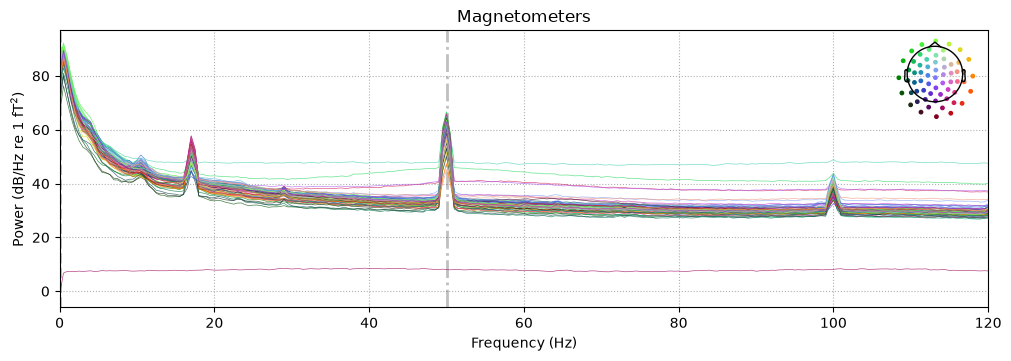

In [12]:
%matplotlib inline  
raw_PSDZ.plot(exclude="bads", picks="mag");

Note the 50 Hz line noise. The frequency of the line noise is 50 Hz in European countries including Russia as well as Asian countries including India and China. It is 60 in South Korea as well as South and North America. In Japan it will be either 50 or 60 Hz depending on the region.

## Inspecting the raw data using the interactive data browser

It is also possible to browse the data using an interactive plot. This will here be illustrated for the OPM Z sensors sensitive to the radial fields:

In [18]:
%matplotlib qt
raw.plot(duration=10, title="Raw", picks=OPMZ);

Channels marked as bad:
['F8 B4 Z', 'F8 B4 Y', 'F8 B4 X', 'T14 H6 Z', 'T14 H6 Y', 'T14 H6 X']


This will open the plot in a new window. Use the arrow keys to move over channels and time. Click on the help button for more information.

**Question 3:** Scroll through the OPM data and identify the following artefacts (include screen dumps in the response):

- The left and right cue onsets
- Eye‑blink  
- A muscle contraction (characterised by high‑frequency activity)  
- The cardiac artefact  

## Inspecting the trigger channels and event labels

So far we have looked at the OPM sensors. The experiment itself is described by the **trigger channels** (`Trigger 1` … `Trigger 11`), which are stimulus (STIM) channels recording the digital pulses sent by the stimulus computer whenever an event occurs — for example an attention cue, a stimulus onset, or a button press. Each event is encoded as an integer *trigger value*, formed by the combination of trigger lines that are high at that moment. Below we first plot the raw trigger pulses.

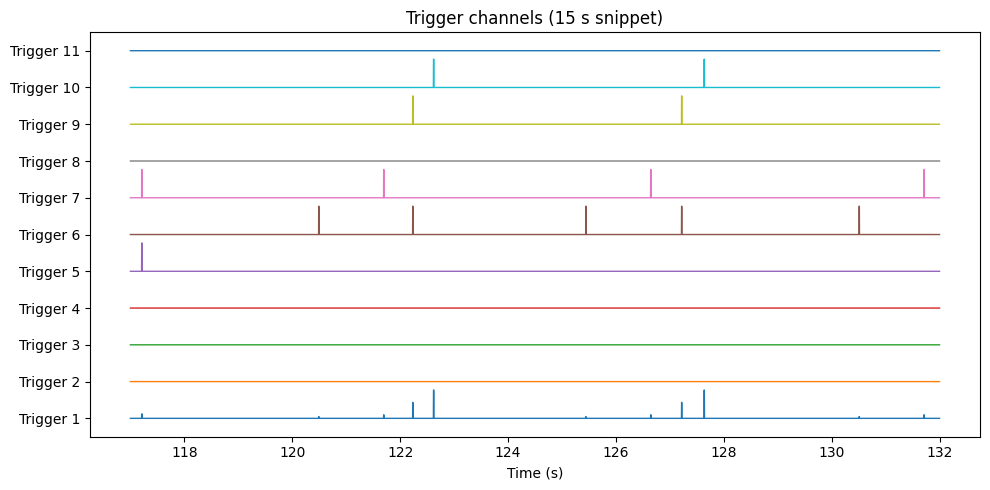

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# The 11 trigger lines are stimulus (STIM) channels
trigger_chs = [ch for ch in raw.ch_names if ch.startswith("Trigger")]

# Extract a 15 s segment containing the first block of trials
tmin, tmax = 117.0, 132.0
data, times = raw.get_data(picks=trigger_chs, tmin=tmin, tmax=tmax, return_times=True)

fig, ax = plt.subplots(figsize=(10, 5))
for i, ch in enumerate(trigger_chs):
    trace = data[i]
    if trace.max() > trace.min():  # normalise each line to 0-1 for display
        trace = (trace - trace.min()) / (trace.max() - trace.min())
    ax.plot(times, trace + i * 1.3, lw=1)  # vertical offset so lines do not overlap

ax.set_yticks([i * 1.3 for i in range(len(trigger_chs))])
ax.set_yticklabels(trigger_chs)
ax.set_xlabel("Time (s)")
ax.set_title("Trigger channels (15 s snippet)")
plt.tight_layout()
plt.show()

Each pulse train above corresponds to one trigger line. Trigger line 1 is a combination of the other trigger lines. Its from this line event codes are derived. 

When the data are stored in BIDS, these pulses are decoded once and saved in a companion `events.tsv` file, where every event is given both its numeric `value` (the trigger code) and a human-readable `trial_type` (the *label*).


**Question 4:** Open the 'events.tsv' directly from the file directory in an editor. Then match the labels according to Trigger 1. Identify at least 4 events. Hint: here is the 'events.tsv' file.

In [ ]:
evttsv = op.join(
    bids_root, "sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_events.tsv"
)
print(evttsv)

/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_events.tsv


## References

[1] Smith, W.S. (1997) *The Scientist and Engineer's Guide to Digital Signal Processing*. California Technical Publishing. ISBN 0-9660176-3-3. Online version: [The Scientist and Engineer's Guide to DSP](https://www.dspguide.com/)
